# Sales Data Analysis and Exploration
**Made by:- Aryan Singh**


## Data Ingestion and Initial Assessment


In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as w
w.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


In [167]:
#Load the datasets from the repository links
cust = 'https://raw.githubusercontent.com/AryanCodex2000/Sales-Data-Analysis-and-Exploration/refs/heads/main/Data/customers.csv'
geo = 'https://raw.githubusercontent.com/AryanCodex2000/Sales-Data-Analysis-and-Exploration/refs/heads/main/Data/geolocation.csv'
oi = 'https://raw.githubusercontent.com/AryanCodex2000/Sales-Data-Analysis-and-Exploration/refs/heads/main/Data/order_items.csv'
pay = 'https://raw.githubusercontent.com/AryanCodex2000/Sales-Data-Analysis-and-Exploration/refs/heads/main/Data/payments.csv'
prod = 'https://raw.githubusercontent.com/AryanCodex2000/Sales-Data-Analysis-and-Exploration/refs/heads/main/Data/products.csv'
sell = 'https://raw.githubusercontent.com/AryanCodex2000/Sales-Data-Analysis-and-Exploration/refs/heads/main/Data/sellers.csv'
ord = 'https://raw.githubusercontent.com/AryanCodex2000/Sales-Data-Analysis-and-Exploration/refs/heads/main/Data/orders.csv'

customers = pd.read_csv(cust)
geolocation = pd.read_csv(geo)
order_items = pd.read_csv(oi)
payments = pd.read_csv(pay)
products = pd.read_csv(prod)
sellers = pd.read_csv(sell)
orders = pd.read_csv(ord)

sellers.sample()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
2899,655220df33262c7e0c4949a147366f94,9951,diadema,SP


In [168]:
orders.sample()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
9322,d34e326c0b15c4b4a481ba1376687e75,4eef378ad98a010b62ff45bf2f9bdcfc,delivered,2018-03-25 11:05:58,2018-03-25 11:30:28,2018-03-26 21:12:02,2018-04-05 20:38:36,2018-04-13 0:00:00


In [169]:
products.sample()

,product_id,product category,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
21871,d93d7e81a8d724c4ef661e75647cf325,babies,50.0,158.0,1.0,1600.0,25.0,9.0,18.0


In [170]:
payments.sample()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
91033,2f7427d25f9d7b23677de76f04079e0e,1,credit_card,1,28.08


In [171]:
order_items.sample()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
98772,e00d3f33450408f4b359426def9f3961,1,ee6c49af1a2de55aa0e076257ab4ab99,1c68394e931a64f90ea236c5ea590300,2018-03-02 7:27:21,144.41,15.76


In [172]:
geolocation.sample()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
706942,49140,-10.908504,-37.03735,barra dos coqueiros,SE


In [173]:
customers.sample()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
95666,1023dd567f41a452ce0c70f981369c63,3dbeb69914c13ee89785281a876f5924,20755,rio de janeiro,RJ


In [174]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [175]:
customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

In [176]:
geolocation.columns

Index(['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state'],
      dtype='object')

In [177]:
order_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

In [178]:
payments.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

In [179]:
sellers.columns

Index(['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state'], dtype='object')

In [180]:
products.columns

Index(['product_id', 'product category', 'product_name_length',
       'product_description_length', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

In [181]:
'''
RELATIONAL DATA CONSOLIDATION: ASSEMBLING THE 'df' MASTER TABLE
Integrating core business entities (excluding geolocation) into a unified view.
'''

# Step 1: Initialize the join by linking product details to order items
df = order_items.merge(products, on='product_id', how='left')

# Step 2: Associate seller attributes with the relevant products
df = df.merge(sellers, on='seller_id', how='left')

# Step 3: Enrich the dataset with transactional order metadata
df = df.merge(orders, on='order_id', how='left')

# Step 4: Link customer profiles to their specific transactions
df = df.merge(customers, on='customer_id', how='left')

# Step 5: Summarize payment data at the order level before merging
# This ensures a 1:1 relationship per order_id and prevents row duplication.
payments_agg = payments.groupby('order_id').agg(
    total_payment=('payment_value', 'sum'),
    payment_type=('payment_type', 'first')
).reset_index()

# Final Step: Append the aggregated financial metrics to the main dataframe
df = df.merge(payments_agg, on='order_id', how='left')

In [182]:
df.sample()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product category,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_payment,payment_type
9153,14f0429b74bbb862693e5a88af6f6f6a,2,be4f6fe1a36e3a7abc3c966be0925070,d20b021d3efdf267a402c402a48ea64b,2017-10-30 3:49:29,22.9,4.52,Furniture Decoration,57.0,472.0,2.0,300.0,80.0,10.0,60.0,14940,ibitinga,SP,f7046a8b240746366664bc7462548824,delivered,2017-10-21 13:30:15,2017-10-24 3:49:29,2017-10-24 17:28:37,2017-10-30 20:54:43,2017-11-09 0:00:00,d615a46ee39d41088222d36e46fb5c03,8190,sao paulo,SP,192.5,UPI


In [183]:
df.columns.tolist()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'product category',
 'product_name_length',
 'product_description_length',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'seller_zip_code_prefix',
 'seller_city',
 'seller_state',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'total_payment',
 'payment_type']

In [184]:
df.shape

(112650, 31)

In [185]:
df.dtypes

,0
order_id,object
order_item_id,int64
product_id,object
seller_id,object
shipping_limit_date,object
price,float64
freight_value,float64
product category,object
product_name_length,float64
product_description_length,float64


In [186]:
df.describe(include='all')

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product category,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_payment,payment_type
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000,111047,111047.000000,111047.000000,111047.000000,112632.000000,112632.000000,112632.000000,112632.000000,112650.000000,112650,112650,112650,112650,112650,112635,111456,110196,112650,112650,112650.000000,112650,112650,112647.000000,112647
unique,98666,NaN,32951,3095,93318,NaN,NaN,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,611,23,98666,7,98112,90174,81017,95664,450,95420,NaN,4110,27,NaN,4
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN,bed table bath,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sao paulo,SP,fc3d1daec319d62d49bfb5e1f83123e9,delivered,2017-07-16 18:19:25,2018-02-24 3:20:27,2018-05-09 15:48:00,2017-07-31 18:03:02,2017-12-20 0:00:00,c8460e4251689ba205045f3ea17884a1,NaN,sao paulo,SP,NaN,credit_card
freq,21,NaN,527,2033,21,NaN,NaN,11115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27983,80342,21,110197,21,23,48,21,604,24,NaN,17808,47449,NaN,85194
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320,NaN,48.775978,787.867029,2.209713,2093.672047,30.153669,16.593766,22.996546,24439.170431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35119.309090,NaN,NaN,180.281186,NaN
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405,NaN,10.025581,652.135608,1.721438,3751.596884,16.153449,13.443483,11.707268,27596.030909,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29866.120801,NaN,NaN,272.849042,NaN
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1001.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1003.000000,NaN,NaN,9.590000,NaN
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000,NaN,42.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000,6429.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11310.000000,NaN,NaN,65.670000,NaN
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000,NaN,52.000000,603.000000,1.000000,700.000000,25.000000,13.000000,20.000000,13568.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24340.000000,NaN,NaN,114.440000,NaN
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000,NaN,57.000000,987.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,27930.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59028.750000,NaN,NaN,195.390000,NaN


<Axes: ylabel='Density'>

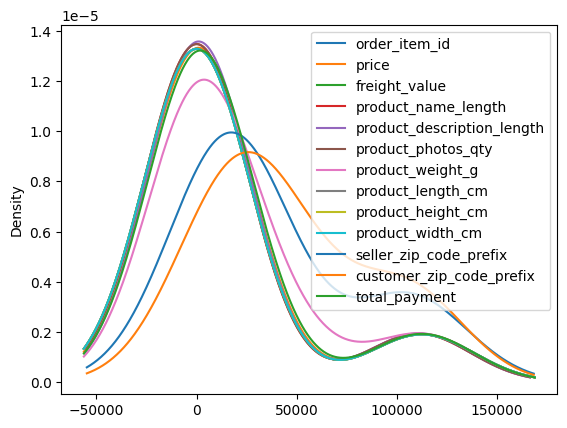

In [187]:
df.describe(include='all').plot(kind='kde')

In [188]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 31 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  object 
 1   order_item_id                  112650 non-null  int64  
 2   product_id                     112650 non-null  object 
 3   seller_id                      112650 non-null  object 
 4   shipping_limit_date            112650 non-null  object 
 5   price                          112650 non-null  float64
 6   freight_value                  112650 non-null  float64
 7   product category               111047 non-null  object 
 8   product_name_length            111047 non-null  float64
 9   product_description_length     111047 non-null  float64
 10  product_photos_qty             111047 non-null  float64
 11  product_weight_g               112632 non-null  float64
 12  product_length_cm             

In [189]:
df.nunique()

,0
order_id,98666
order_item_id,21
product_id,32951
seller_id,3095
shipping_limit_date,93318
price,5968
freight_value,6999
product category,73
product_name_length,66
product_description_length,2960


#Now cleaning the data and duplicates removal if necessary


In [190]:
df.duplicated().sum()

np.int64(0)

## Lets check for the data types of the columns if needed to be changed then will change or else remain the same

In [191]:
date_cols = ['shipping_limit_date', 'order_purchase_timestamp', 'order_approved_at','order_delivered_carrier_date',
             'order_delivered_customer_date','order_estimated_delivery_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    print(f'{col} has now dtype of {df[col].dtype}')


shipping_limit_date has now dtype of datetime64[ns]
order_purchase_timestamp has now dtype of datetime64[ns]
order_approved_at has now dtype of datetime64[ns]
order_delivered_carrier_date has now dtype of datetime64[ns]
order_delivered_customer_date has now dtype of datetime64[ns]
order_estimated_delivery_date has now dtype of datetime64[ns]


In [192]:
for col in df.columns:
  if df[col].isna().sum() > 0:
    print(f'''"{col}" of dtype "{df[col].dtype}" has {df[col].isna().sum()} missing values with {round(df[col].isna().sum()/df.shape[0]*100,2)}%''')

"product category" of dtype "object" has 1603 missing values with 1.42%
"product_name_length" of dtype "float64" has 1603 missing values with 1.42%
"product_description_length" of dtype "float64" has 1603 missing values with 1.42%
"product_photos_qty" of dtype "float64" has 1603 missing values with 1.42%
"product_weight_g" of dtype "float64" has 18 missing values with 0.02%
"product_length_cm" of dtype "float64" has 18 missing values with 0.02%
"product_height_cm" of dtype "float64" has 18 missing values with 0.02%
"product_width_cm" of dtype "float64" has 18 missing values with 0.02%
"order_approved_at" of dtype "datetime64[ns]" has 15 missing values with 0.01%
"order_delivered_carrier_date" of dtype "datetime64[ns]" has 1194 missing values with 1.06%
"order_delivered_customer_date" of dtype "datetime64[ns]" has 2454 missing values with 2.18%
"total_payment" of dtype "float64" has 3 missing values with 0.0%
"payment_type" of dtype "object" has 3 missing values with 0.0%


In [193]:
## Dropping null rows with 0.05% null values
list5 = ['product_weight_g', 'product_length_cm', 'product_height_cm',
         'product_width_cm', 'order_approved_at', 'total_payment', 'payment_type']

df.dropna(subset=list5, inplace=True)

for col in list5:
    print(f"{col}: {df[col].isna().sum()} nulls remaining")

product_weight_g: 0 nulls remaining
product_length_cm: 0 nulls remaining
product_height_cm: 0 nulls remaining
product_width_cm: 0 nulls remaining
order_approved_at: 0 nulls remaining
total_payment: 0 nulls remaining
payment_type: 0 nulls remaining


In [194]:
# filling of rest null values

df['product category'] = df['product category'].fillna('Unknown')

num_cols = ['product_name_length', 'product_description_length', 'product_photos_qty']

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

date_cols = ['order_delivered_carrier_date', 'order_delivered_customer_date']

for col in date_cols:
    mean_ts = pd.to_datetime(df[col].dropna().astype('int64').median())
    df[col] = df[col].fillna(mean_ts)


In [195]:
for col in df.columns:
  if df[col].isna().sum() > 0:
    print(f'''"{col}" of dtype "{df[col].dtype}" has {df[col].isna().sum()} missing values with {round(df[col].isna().sum()/df.shape[0]*100,2)}%''')

# Now lets do the data cleaning for the geolocation dataset

In [196]:
geolocation.sample()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
189910,7434,-23.41322,-46.319963,aruja,SP


In [197]:
geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [198]:
geolocation.describe(include='all')

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,1.000163e+06,1.000163e+06,1.000163e+06,1000163,1000163
unique,NaN,NaN,NaN,8011,27
top,NaN,NaN,NaN,sao paulo,SP
freq,NaN,NaN,NaN,135800,404268
mean,3.657417e+04,-2.117615e+01,-4.639054e+01,NaN,NaN
std,3.054934e+04,5.715866e+00,4.269748e+00,NaN,NaN
min,1.001000e+03,-3.660537e+01,-1.014668e+02,NaN,NaN
25%,1.107500e+04,-2.360355e+01,-4.857317e+01,NaN,NaN
50%,2.653000e+04,-2.291938e+01,-4.663788e+01,NaN,NaN
75%,6.350400e+04,-1.997962e+01,-4.376771e+01,NaN,NaN


In [199]:
geolocation.nunique()

,0
geolocation_zip_code_prefix,19015
geolocation_lat,717360
geolocation_lng,717613
geolocation_city,8011
geolocation_state,27


In [200]:
geolocation.duplicated().sum()

np.int64(261831)

In [201]:
geolocation.drop_duplicates(inplace=True)
geolocation.duplicated().sum()

np.int64(0)

In [202]:
geolocation.shape

(738332, 5)

In [203]:
geolocation.isna().sum()

,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0


# Exploratory Data Analysis

In [204]:
# Collect the distinct customer cities available in the data
unique_cities = df['customer_city'].dropna().unique()

print(f"Total number of unique cities: {len(unique_cities)}")
print(f"Sample of cities: {unique_cities[:10]}")

Total number of unique cities: 4109
Sample of cities: ['campos dos goytacazes' 'santa fe do sul' 'para de minas' 'atibaia'
 'varzea paulista' 'uberaba' 'guararapes' 'praia grande' 'santos'
 'jandira']


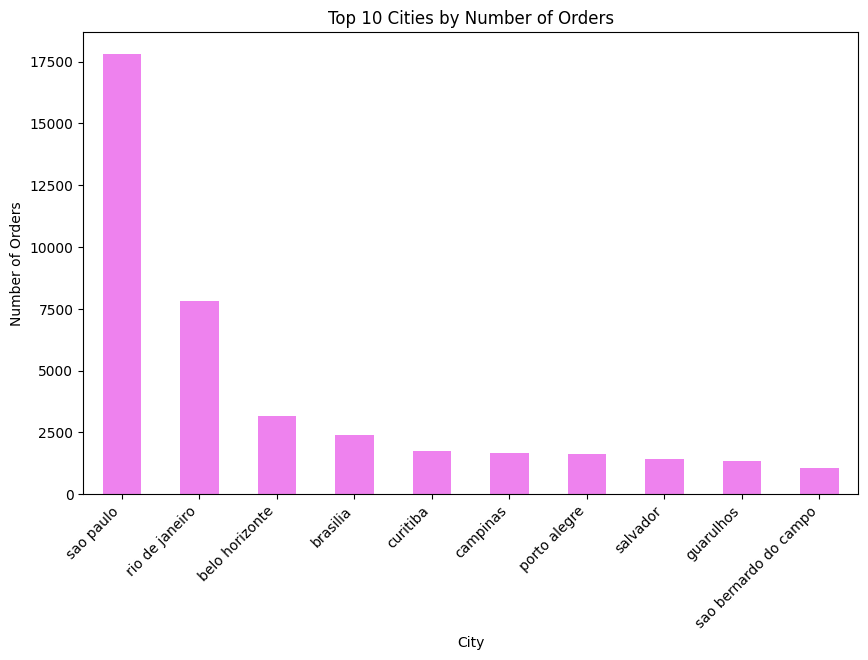

In [205]:
#  Visual summary of the top 10 cities by order count

plt.figure(figsize=(10, 6))
df['customer_city'].value_counts().head(10).plot(kind='bar', color='Violet')
plt.title('Visual summary of the top 10 cities by order count by Number of Orders')
plt.xlabel('City')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.show()

#Number of orders placed in 2017


In [206]:
orders_2017 = df[df['order_purchase_timestamp'].dt.year == 2017]['order_id'].nunique()
print(f"Total unique orders placed in 2017: {orders_2017}")

Total unique orders placed in 2017: 44549


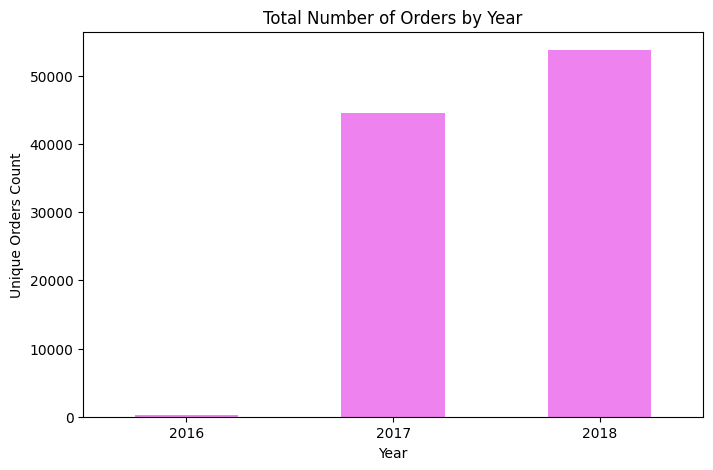

In [207]:
plt.figure(figsize=(8, 5))
df.groupby(df['order_purchase_timestamp'].dt.year)['order_id'].nunique().plot(kind='bar', color='violet')
plt.title('Total Number of Orders by Year')
plt.xlabel('Year')
plt.ylabel('Unique Orders Count')
plt.xticks(rotation=0)
plt.show()

#Total Sales per Category


In [208]:
sales_per_category = df.groupby('product category')['price'].sum().sort_values(ascending=False)

print("Total sales :")
print(sales_per_category.T)

Total sales :
product category
HEALTH BEAUTY                                       1258546.37
Watches present                                     1205005.68
bed table bath                                      1036854.69
sport leisure                                        987979.99
computer accessories                                 911954.32
Furniture Decoration                                 729506.89
Cool Stuff                                           635050.88
housewares                                           632248.66
automotive                                           592720.11
Garden tools                                         485121.46
toys                                                 483946.60
babies                                               409830.89
perfumery                                            399124.87
telephony                                            323569.53
Furniture office                                     273960.70
stationary store        

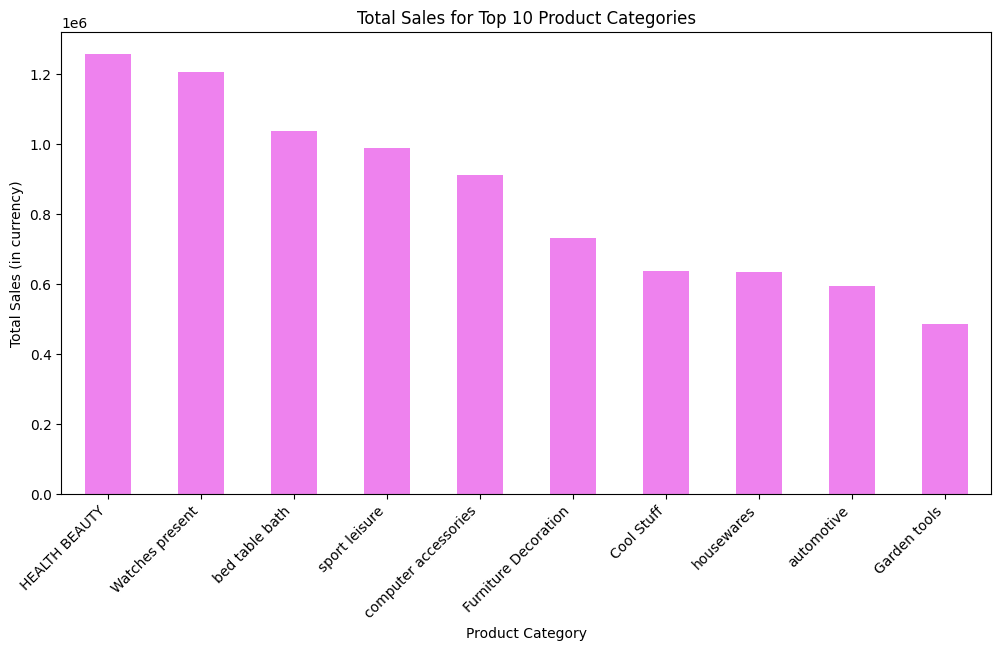

In [209]:
plt.figure(figsize=(12, 6))
sales_per_category.head(10).plot(kind='bar', color='violet')
plt.title('Total Sales for Top 10 Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Total Sales (in currency)')
plt.xticks(rotation=45, ha='right')
plt.show()

#Percentage of the orders that were paid in installments

In [210]:
# Count unique orders with more than 1 installment
installment_orders = payments[payments['payment_installments'] > 1]['order_id'].nunique()

# Count total unique orders in the payments dataset
total_orders = payments['order_id'].nunique()

percentage_installments = (installment_orders / total_orders) * 100
print(f"Percentage of orders paid in installments: {percentage_installments:.2f}%")

Percentage of orders paid in installments: 51.46%


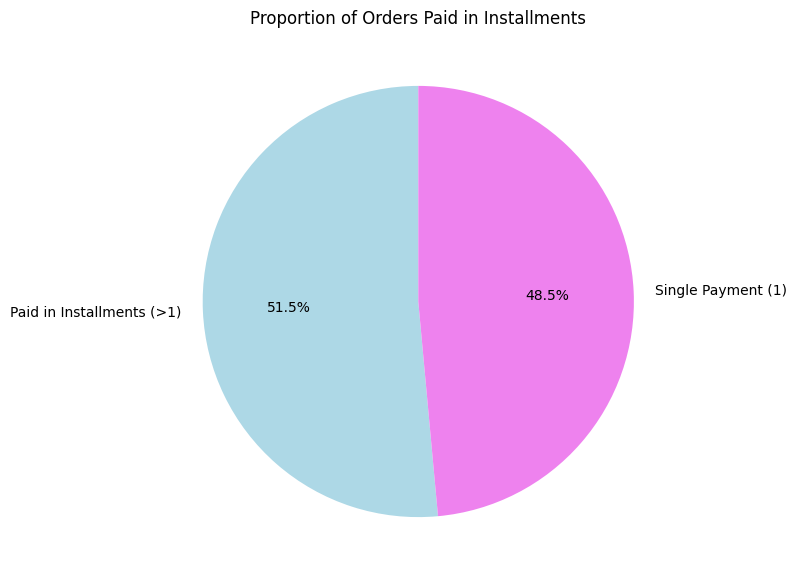

In [211]:
plt.figure(figsize=(7, 7))
labels = ['Paid in Installments (>1)', 'Single Payment (1)']
sizes = [installment_orders, total_orders - installment_orders]
colors = ['lightblue', 'violet']

plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90,)
plt.title('Proportion of Orders Paid in Installments')
plt.show()

#Number of customers from each state

In [212]:
# Group by state and count unique customer IDs
customers_per_state = df.groupby('customer_state')['customer_unique_id'].nunique().sort_values(ascending=False)

print("Number of customers:")
print(customers_per_state)

Number of customers:
customer_state
SP    39972
RJ    12300
MG    11174
RS     5245
PR     4838
SC     3513
BA     3257
DF     2061
ES     1956
GO     1942
PE     1605
CE     1304
PA      944
MT      872
MA      718
MS      688
PB      516
PI      480
RN      471
AL      399
SE      338
TO      272
RO      235
AM      142
AC       77
AP       67
RR       45
Name: customer_unique_id, dtype: int64


#Number of orders per month in 2018

In [213]:
# Filter for 2018 and group by month to count unique orders
orders_2018 = df[df['order_purchase_timestamp'].dt.year == 2018]
monthly_orders_2018 = orders_2018.groupby(orders_2018['order_purchase_timestamp'].dt.month)['order_id'].nunique()

print(monthly_orders_2018)



order_purchase_timestamp
1    7220
2    6694
3    7188
4    6934
5    6853
6    6160
7    6273
8    6452
9       1
Name: order_id, dtype: int64


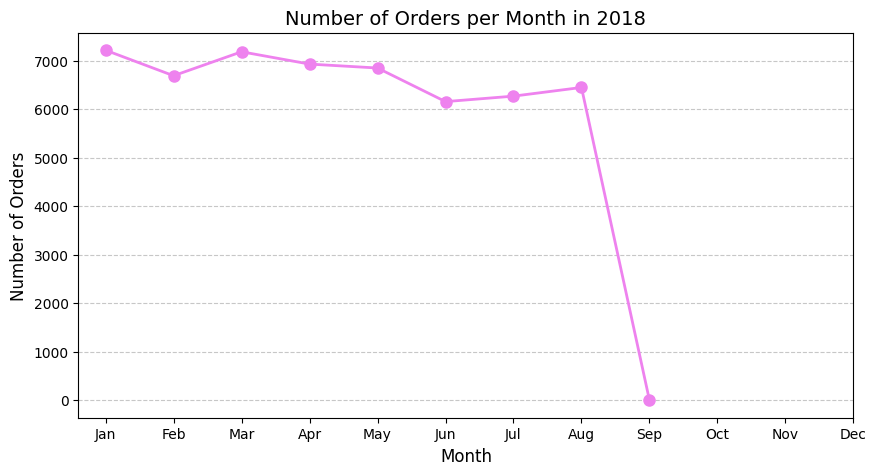

In [214]:
# Create the chart for this metric
plt.figure(figsize=(10, 5))
monthly_orders_2018.plot(kind='line', marker='o', color='violet', linewidth=2, markersize=8)
plt.title('Number of Orders per Month in 2018', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Average number of products per order, grouped by customer city

In [215]:
#count products per order per city
products_per_order = df.groupby(['order_id', 'customer_city'])['product_id'].count().reset_index()
products_per_order.rename(columns={'product_id': 'product_count'}, inplace=True)

# find the average product count per city
avg_products_city = products_per_order.groupby('customer_city')['product_count'].mean().sort_values(ascending=False)

print("Top 5 cities by average products per order:")
print(avg_products_city.head())

Top 5 cities by average products per order:
customer_city
padre carvalho    7.0
celso ramos       6.5
datas             6.0
candido godoi     6.0
matias olimpio    5.0
Name: product_count, dtype: float64


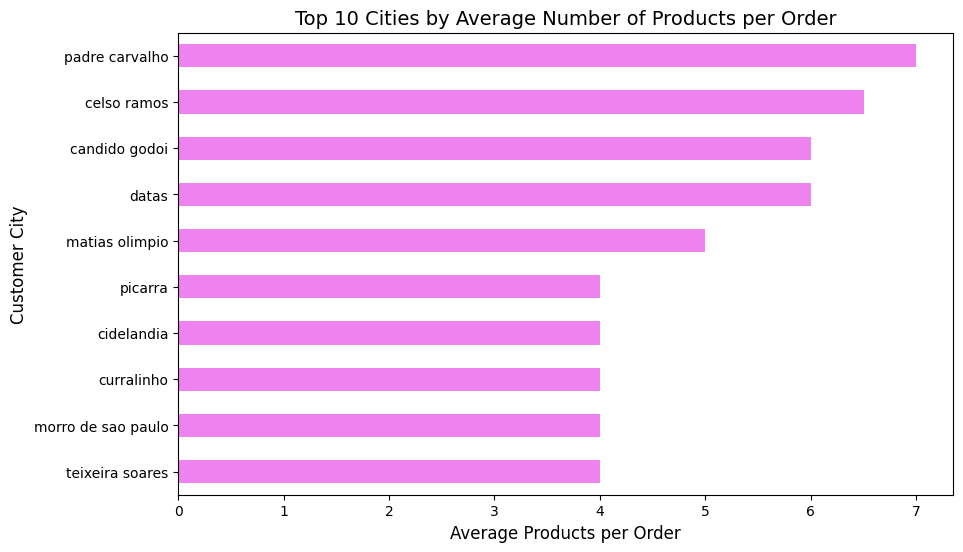

In [216]:
# Create the chart for this metric (Visual summary of the top 10 cities by order count)
plt.figure(figsize=(10, 6))
avg_products_city.head(10).sort_values().plot(kind='barh', color='violet')
plt.title('Visual summary of the top 10 cities by order count by Average Number of Products per Order', fontsize=14)
plt.xlabel('Average Products per Order', fontsize=12)
plt.ylabel('Customer City', fontsize=12)
plt.show()

#Percentage of total revenue contributed by each product category

In [217]:
# Calculate revenue per category
revenue_by_cat = df.groupby('product category')['price'].sum().sort_values(ascending=False)

# Group top 5 and combine the rest into 'Others'
top_5_cat = revenue_by_cat.head(5)
others_cat = pd.Series({'Others': revenue_by_cat.iloc[5:].sum()})
combined_revenue = pd.concat([top_5_cat, others_cat])

# Convert the grouped revenue values to percentage share
total_revenue = combined_revenue.sum()
print((combined_revenue / total_revenue) * 100)

HEALTH BEAUTY            9.262639
Watches present          8.868591
bed table bath           7.631034
sport leisure            7.271327
computer accessories     6.711794
Others                  60.254615
dtype: float64


In [ ]:
# Create the chart for this metric
plt.figure(figsize=(8, 8))

# Swapping the purple tones for a cohesive Violet/Purple gradient
# These shades move from deep violet to a soft lavender mist
colors = ['#4B0082', '#6A5ACD', '#7B68EE', '#9370DB', '#B19CD9', '#E6E6FA']

plt.pie(combined_revenue, labels=combined_revenue.index, autopct='%1.1f%%',
        colors=colors, startangle=90, pctdistance=0.85, wedgeprops=dict(width=0.3, edgecolor='w'))

# Add a white center circle so the pie chart appears as a donut
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Percentage of Total Revenue by Top Product Categories', fontsize=14)
plt.show()

#Correlation between product price and the num ber of times a product has been purchased

In [ ]:
# Group by product_id to get total purchases and average price
product_stats = df.groupby('product_id').agg(
    total_purchases=('order_id', 'count'),
    avg_price=('price', 'mean')
).reset_index()

# Measure the linear relationship between average price and purchase count
correlation = product_stats['avg_price'].corr(product_stats['total_purchases'])
print(f"Correlation between price and times purchased: {correlation:.4f}")

In [ ]:
# Create the chart for this metric
plt.figure(figsize=(10, 6))
sns.regplot(data=product_stats, x='avg_price', y='total_purchases',
            scatter_kws={'color': 'mediumpurple', 'alpha': 0.5},
            line_kws={'color': 'violet'})

plt.title(f'Correlation: Product Price vs Times Purchased (r = {correlation:.2f})', fontsize=14)
plt.xlabel('Average Price', fontsize=12)
plt.ylabel('Number of Times Purchased', fontsize=12)
plt.show()

#Total revenue generated by each seller and rank them by revenue

In [ ]:
# Group by seller_id and sum the price to get total revenue
seller_revenue = df.groupby('seller_id')['price'].sum().sort_values(ascending=False)

print("Top 5 Sellers by Revenue:")
print(seller_revenue.head())

In [ ]:
# Create the chart for this metric (Top 10 Sellers)
plt.figure(figsize=(12, 6))
seller_revenue.head(10).plot(kind='bar', color='pink', edgecolor='violet')
plt.title('Top 10 Sellers Ranked by Total Revenue', fontsize=14)
plt.xlabel('Seller ID', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

#Moving average of order values for each customers

In [ ]:
# Convert purchase timestamps and order rows for customer-level sequencing
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df_sorted = df.sort_values(by=['customer_unique_id', 'order_purchase_timestamp'])

# Calculate the expanding (moving) average of the price per customer
df_sorted['moving_avg_order_value'] = df_sorted.groupby('customer_unique_id')['price'].transform(lambda x: x.expanding().mean())

# Pick the three customers with the highest order frequency for plotting
top_customers = df_sorted['customer_unique_id'].value_counts().head(3).index

In [ ]:
# Create the chart for this metric
plt.figure(figsize=(10, 6))
colors = ['indigo', 'mediumorchid', 'mediumpurple']

for i, cust_id in enumerate(top_customers):
    cust_data = df_sorted[df_sorted['customer_unique_id'] == cust_id].reset_index()
    plt.plot(cust_data.index + 1, cust_data['moving_avg_order_value'],
             marker='o', linestyle='-', linewidth=2, color=colors[i],
             label=f'Customer {i+1} ({cust_id[:6]}...)')

plt.title('Moving Average of Order Values (Top 3 Frequent Customers)', fontsize=14, color='indigo')
plt.xlabel('Order Sequence Number', fontsize=12)
plt.ylabel('Moving Average ($)', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

#Cumulative sales per month for each year

In [ ]:
# Derive year and month fields from the purchase timestamp
df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df['order_purchase_timestamp'].dt.month

# Summarize revenue by year and month
monthly_sales = df.groupby(['year', 'month'])['price'].sum().reset_index()

# Build cumulative monthly sales inside every year
monthly_sales['cumulative_sales'] = monthly_sales.groupby('year')['price'].cumsum()

In [ ]:
# Create the chart for this metric
plt.figure(figsize=(12, 6))
years = monthly_sales['year'].unique()
green_shades = ['#d8bfd8', '#7b68ee', '#4b0082'] # Light to dark purple

for i, year in enumerate(years):
    year_data = monthly_sales[monthly_sales['year'] == year]
    plt.fill_between(year_data['month'], year_data['cumulative_sales'],
                     color=green_shades[i % len(green_shades)], alpha=0.6, label=str(year))
    plt.plot(year_data['month'], year_data['cumulative_sales'],
             color=green_shades[i % len(green_shades)], linewidth=2)

plt.title('Cumulative Sales Per Month for Each Year', fontsize=14, color='indigo')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Cumulative Sales ($)', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Year')
plt.show()

#Year over year growth rate of total sales

In [ ]:
# Summarize overall sales by year
yearly_sales = df.groupby('year')['price'].sum().reset_index()

# Compute year-over-year percentage growth
yearly_sales['yoy_growth'] = yearly_sales['price'].pct_change() * 100

print(yearly_sales[['year', 'yoy_growth']].dropna())

In [ ]:
# Create the chart for this metric
plt.figure(figsize=(8, 5))
plt.plot(yearly_sales['year'].astype(str), yearly_sales['yoy_growth'],
         marker='D', markersize=12, color='blueviolet', linestyle='-.', linewidth=2.5, markeredgecolor='indigo')

plt.axhline(0, color='indigo', linewidth=1.5, linestyle='--') # 0% growth baseline
plt.title('Year-over-Year Growth Rate of Total Sales', fontsize=14, color='indigo')
plt.xlabel('Year', fontsize=12)
plt.ylabel('YoY Growth Rate (%)', fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.show()

#Retention rate of customers

In [ ]:
# Identify the first observed order date for each customer
first_purchases = df.groupby('customer_unique_id')['order_purchase_timestamp'].min().reset_index()
first_purchases.columns = ['customer_unique_id', 'first_purchase_date']

# Join first purchase dates back and calculate the elapsed days
merged = pd.merge(df, first_purchases, on='customer_unique_id')
merged['days_since_first'] = (merged['order_purchase_timestamp'] - merged['first_purchase_date']).dt.days

# A customer is retained if they made a purchase between 1 and 180 days (approx 6 months) later
retained = merged[(merged['days_since_first'] > 0) & (merged['days_since_first'] <= 180)]['customer_unique_id'].nunique()
total_customers = first_purchases['customer_unique_id'].nunique()

retention_rate = (retained / total_customers) * 100
print(f"6-Month Retention Rate: {retention_rate:.2f}%")

In [ ]:
# Create the chart for this metric (Polar Gauge)
plt.figure(figsize=(6, 6))
ax = plt.subplot(111, polar=True)

# Create the filled gauge representing the percentage
theta = np.linspace(0, 2 * np.pi * (retention_rate / 100), 100)
r = np.ones(100)
ax.fill_between(theta, 0, r, color='plum', alpha=0.8)

ax.set_yticklabels([]) # Hide radial ticks
ax.set_xticks([])      # Hide angular ticks
ax.spines['polar'].set_visible(False)

plt.text(0, 0, f'{retention_rate:.2f}%', ha='center', va='center', fontsize=30, color='indigo', weight='bold')
plt.title('6-Month Customer Retention Rate', color='indigo', fontsize=14, pad=20)
plt.show()

# Top 3 customers who spent the most money in each year

In [ ]:
# Calculate total spent per customer per year
yearly_cust_sales = df.groupby(['year', 'customer_unique_id'])['price'].sum().reset_index()

# Rank and get the top 3 for each year
top_3_per_year = yearly_cust_sales.sort_values(['year', 'price'], ascending=[True, False]).groupby('year').head(3)

print("Top 3 Spenders per Year:")
print(top_3_per_year)

In [ ]:
# Create the chart for this metric
plt.figure(figsize=(10, 6))
years = top_3_per_year['year'].unique()

for year in years:
    year_data = top_3_per_year[top_3_per_year['year'] == year]
    # Plot as a scatter point
    plt.scatter([year] * len(year_data), year_data['price'], s=300, color='mediumorchid', alpha=0.7, edgecolors='indigo')

    # Annotate each point with the customer's ID snippet
    for _, row in year_data.iterrows():
        plt.annotate(row['customer_unique_id'][:6] + '...',
                     (year + 0.05, row['price']),
                     fontsize=10, color='indigo', va='center')

plt.title('Top 3 Customers by Total Spend Each Year', fontsize=14, color='purple')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Spent ($)', fontsize=12)
plt.xticks(years)
plt.grid(True, linestyle=':', alpha=0.6)
# Increase x-axis limit slightly so text doesn't cut off
plt.xlim(years.min() - 0.5, years.max() + 0.8)
plt.show()